In [677]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### 🛍 Online Retail Data Analysis

This notebook contains the full workflow for analyzing the Online Retail dataset to understand sales trends and customer behaviour.

#### data pull

In [678]:
df = pd.read_excel("../data/online-retail-dataset.xlsx")

#### data inspection

In [679]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [680]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [681]:
null_info = df.isnull().sum().reset_index()
null_info.columns = ['Column', 'Null Count']
null_info = null_info[null_info['Null Count'] > 0]

In [682]:
duplicates = df[df.duplicated()].copy()
cols_with_nulls = ['Description', 'CustomerID']
merge_columns = [col for col in df.columns if col not in cols_with_nulls]
duplicate_counts = (
    duplicates.groupby(merge_columns)
    .size()
    .reset_index(name='DuplicateCount')
)
duplicates = duplicates.merge(duplicate_counts, on=merge_columns, how='left')
duplicates = duplicates.sort_values(by='DuplicateCount', ascending=False).reset_index(drop=True)

#### Data cleaning & filtering

In [683]:
# convert types
cdf = df.copy() # => copied so original df remains unchanged
cdf['InvoiceNo'] = cdf['InvoiceNo'].astype('string')
cdf['StockCode'] = cdf['StockCode'].astype('string')
cdf['Description'] = cdf['Description'].astype('string')
cdf['Country'] = cdf['Country'].astype('string')
cdf['CustomerID'] = pd.to_numeric(cdf['CustomerID'], errors='coerce').astype('Int64')

In [684]:
# Standardize transaction descriptions

cdf['StockCode'] = cdf['StockCode'].str.upper()
cdf['OriginalDescription'] = cdf['Description']
cdf_with_null_desc = cdf.copy()
cdf_with_null_desc['Description'] = cdf_with_null_desc['Description'].fillna('NaN')
grouped = (
    cdf_with_null_desc.groupby(['StockCode', 'Description'])
    .size()
    .reset_index(name='Count')
)
stockcodes = {}
for _, row in grouped.iterrows():
    stockcode = row['StockCode']
    description = row['Description']
    count = row['Count']

    if stockcode not in stockcodes:
        stockcodes[stockcode] = {}

    stockcodes[stockcode][description] = count
most_common_desc = {
    code: max(descs.items(), key=lambda x: x[1])[0]
    for code, descs in stockcodes.items()
}
cdf['StandardizedDescription'] = cdf['StockCode'].map(most_common_desc).astype('string')
cdf['StandardizedDescription'] = cdf['StandardizedDescription'].replace('NaN', pd.NA)
cdf['Description'] = cdf['StandardizedDescription'].fillna(cdf['OriginalDescription'])
cdf.drop(columns=['StandardizedDescription'], inplace=True)


In [685]:
# Add totalprice column
cdf['TotalPrice'] = cdf['Quantity'] * cdf['UnitPrice']

In [686]:
# Convert dates and extract time features
cdf['InvoiceDate'] = pd.to_datetime(cdf['InvoiceDate'], errors='coerce')
cdf['Year'] = cdf['InvoiceDate'].dt.year
cdf['Month'] = cdf['InvoiceDate'].dt.month
cdf['MonthYear'] = cdf['InvoiceDate'].dt.to_period('M')
cdf['YearQuarter'] = df['InvoiceDate'].dt.to_period('Q')
cdf['Time'] = cdf['InvoiceDate'].dt.time
cdf['Hour'] = cdf['InvoiceDate'].dt.hour
cdf['Minute'] = cdf['InvoiceDate'].dt.minute
cdf['TimeOfDay'] = pd.cut(cdf['Hour'], bins=[0, 6, 12, 18, 24], 
labels=['Night', 'Morning', 'Afternoon', 'Evening'], right=False,
include_lowest=True)

In [687]:
# Tag missing values
cdf['MissingCustomerID'] = cdf['CustomerID'].isna()
cdf['MissingDescription'] = cdf['Description'].isna()

# Tag Valid Sales
cdf['IsValidSale'] = (
    (cdf['Quantity'] > 0) &
    (cdf['UnitPrice'] > 0) &
    (cdf['InvoiceNo'].str.startswith('C') == False)
)

# Tag Valid Cancellation/Returns
cdf['IsValidReturn'] = (
    (cdf['Quantity'] < 0) &
    (cdf['UnitPrice'] > 0) &
    (cdf['InvoiceNo'].str.startswith('C'))
)

In [688]:
# Remove duplicates
cdf = cdf.drop_duplicates()

In [689]:
# grab only valid transactions (excluding negative quants and zeroed prices)
valid_txns = cdf[cdf['IsValidSale'] | cdf['IsValidReturn']].copy()

In [690]:
# filter sales and returns and non-product key words
non_product_keywords = ["FEE", "MANUAL", "ADJUST", "POSTAGE", "CREDIT", "CHARGES", "SAMPLES", "Discount"]
pattern = '|'.join(non_product_keywords)

filtered_valid_txns = valid_txns[~valid_txns["Description"].str.contains(pattern, case=False, na=False)].copy()
# print(len(filtered_valid_txns))
sales_df = valid_txns[valid_txns["IsValidSale"]].copy()

filtered_sales_df = sales_df[~sales_df["Description"].str.contains(pattern, case=False, na=False)].copy()
# print(len(filtered_sales_df))
returns_df = valid_txns[valid_txns["IsValidReturn"]].copy()

filtered_returns_df = returns_df[~returns_df["Description"].str.contains(pattern, case=False, na=False)].copy()
# print(len(filtered_returns_df))

#### Data Analysis

In [691]:
# Total sales
total_sales = filtered_sales_df["TotalPrice"].sum()
net_total = filtered_valid_txns["TotalPrice"].sum()
total_num_orders = filtered_sales_df["InvoiceNo"].nunique()
avg_order_value = filtered_sales_df.groupby("InvoiceNo")["TotalPrice"].sum().mean()
num_customers = filtered_sales_df['CustomerID'].nunique()
total_sales, total_num_orders, avg_order_value

print(f"Total Sales: £{total_sales:,.2f}")
print(f"Net Total: £{net_total:,.2f}")
print(f"Average Order Value: £{avg_order_value:,.2f}")
print(f"Number of Orders: {total_num_orders}")
print(f"Number of Customers: {num_customers}")

Total Sales: £10,166,314.60
Net Total: £9,684,024.51
Average Order Value: £514.26
Number of Orders: 19769
Number of Customers: 4333


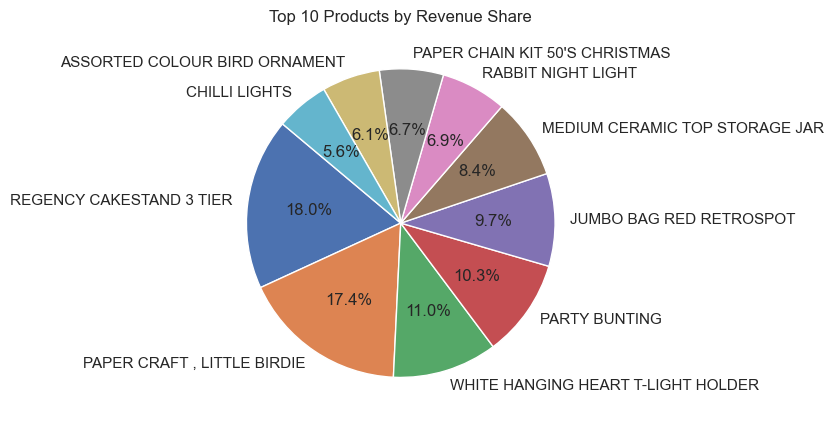

In [692]:
top_product_sales = filtered_sales_df.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).head(10)

# Plot pie chart
plt.figure(figsize=(8, 8))
plt.pie(
    top_product_sales,
    labels=top_product_sales.index,
    autopct='%1.1f%%',
    startangle=140
)
plt.title("Top 10 Products by Revenue Share")
plt.tight_layout()
plt.show()

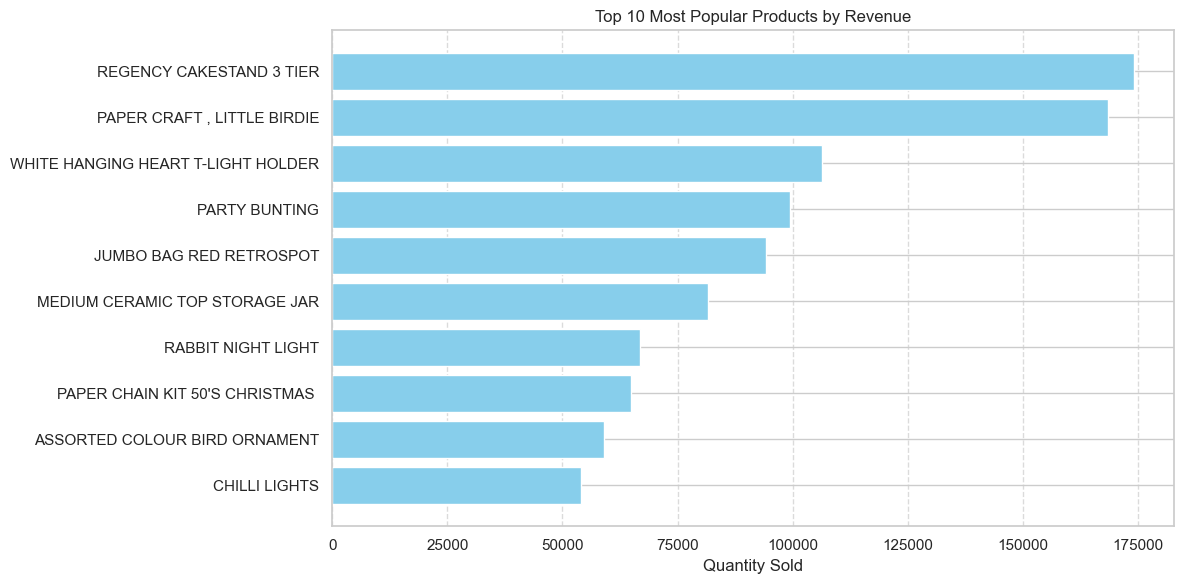

Description
REGENCY CAKESTAND 3 TIER              174156.54
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106415.23
PARTY BUNTING                          99445.23
JUMBO BAG RED RETROSPOT                94159.81
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
RABBIT NIGHT LIGHT                     66870.03
PAPER CHAIN KIT 50'S CHRISTMAS         64875.59
ASSORTED COLOUR BIRD ORNAMENT          58927.62
CHILLI LIGHTS                          54096.36
Name: TotalPrice, dtype: float64


In [693]:
top_product_sales = filtered_sales_df.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).head(10)

# Extract labels and values
product_description = top_product_sales.index.tolist()
quantities = top_product_sales.tolist()

# Plot using raw matplotlib
plt.figure(figsize=(12, 6))
plt.barh(product_description, quantities, color='skyblue')
plt.xlabel("Quantity Sold")
plt.title("Top 10 Most Popular Products by Revenue")
plt.gca().invert_yaxis()  # highest bar at the top
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
print(top_product_sales)

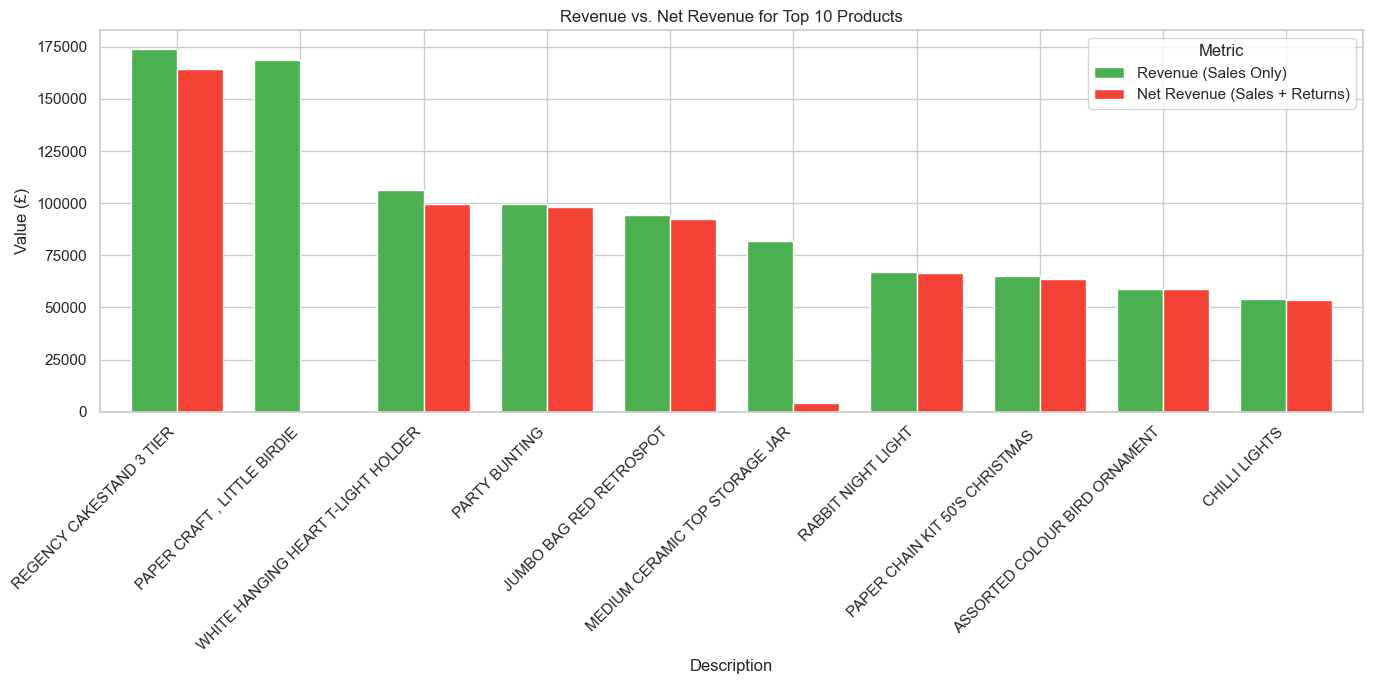

Description
REGENCY CAKESTAND 3 TIER              174156.540
PAPER CRAFT , LITTLE BIRDIE           168469.600
WHITE HANGING HEART T-LIGHT HOLDER    106415.230
PARTY BUNTING                          99445.230
JUMBO BAG RED RETROSPOT                94159.810
                                         ...    
HAPPY BIRTHDAY CARD TEDDY/CAKE             0.950
PINK CRYSTAL GUITAR PHONE CHARM            0.850
VINTAGE BLUE TINSEL REEL                   0.840
HEN HOUSE W CHICK IN NEST                  0.420
PADS TO MATCH ALL CUSHIONS                 0.003
Name: TotalPrice, Length: 3762, dtype: float64


In [694]:
# Helper to exclude descriptions with 'POSTAGE' & 'Manual'
def exclude_postage(series):
    return series[~series.index.str.contains(pattern, case=False)]

# Revenue from sales only
top_products_revenue = (
    filtered_sales_df.groupby("Description")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
)

# Net revenue (sales + returns)
top_products_revenue_net = (
    filtered_valid_txns.groupby("Description")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
)

# Exclude 'POSTAGE'
top_products_revenue_excl = exclude_postage(top_products_revenue)
top_products_revenue_net_excl = exclude_postage(top_products_revenue_net)

# Get top 10 consistent product names based on sales revenue
top_descriptions = top_products_revenue_excl.head(10).index

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Revenue (Sales Only)': top_products_revenue_excl[top_descriptions],
    'Net Revenue (Sales + Returns)': top_products_revenue_net_excl[top_descriptions],
})

# Plot comparison
comparison_df.plot(
    kind='bar',
    figsize=(14, 7),
    width=0.75,
    color=['#4CAF50', '#F44336']
)
plt.title("Revenue vs. Net Revenue for Top 10 Products")
plt.ylabel("Value (£)")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

print(top_products_revenue_excl)

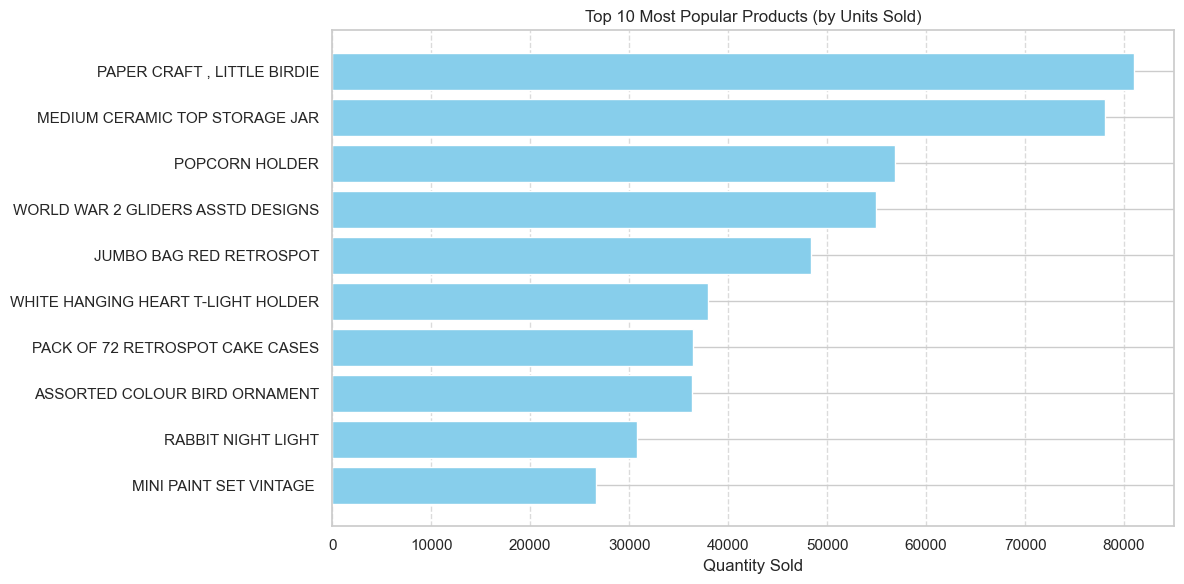

In [695]:
most_units_sold = (
    filtered_sales_df.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

# Extract labels and values
product_description = most_units_sold.index.tolist()
quantities = most_units_sold.values.tolist()

# Plot using raw matplotlib
plt.figure(figsize=(12, 6))
plt.barh(product_description, quantities, color='skyblue')
plt.xlabel("Quantity Sold")
plt.title("Top 10 Most Popular Products (by Units Sold)")
plt.gca().invert_yaxis()  # highest bar at the top
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

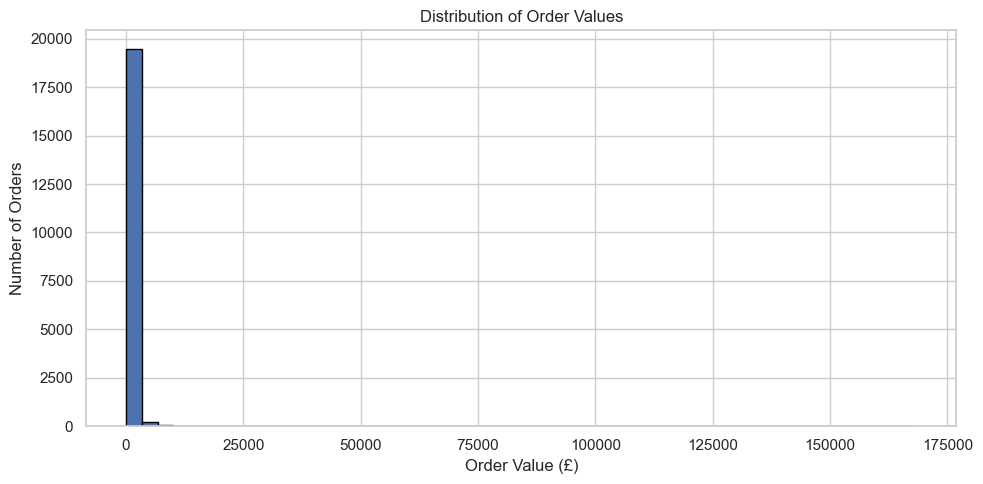

InvoiceNo
536365    139.12
536366     22.20
536367    278.73
536368     70.05
536369     17.85
           ...  
581583    124.60
581584    140.64
581585    329.05
581586    339.20
581587    249.45
Name: TotalPrice, Length: 19769, dtype: float64


In [696]:
order_values = filtered_sales_df.groupby('InvoiceNo')['TotalPrice'].sum()

plt.figure(figsize=(10, 5))
plt.hist(order_values, bins=50, edgecolor='black')
plt.title("Distribution of Order Values")
plt.xlabel("Order Value (£)")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.grid(True)
plt.show()

print(order_values)

In [697]:
# Sales revenue per product
product_sales = filtered_sales_df.groupby('Description')['TotalPrice'].sum()

# Return revenue per product
product_returns = filtered_returns_df.groupby('Description')['TotalPrice'].sum()

product_return_analysis = pd.DataFrame({
    'SalesRevenue': product_sales,
    'ReturnRevenue': product_returns
}).fillna(0)

# Calculate return rate (% of sales returned)
product_return_analysis['ReturnRate (%)'] = np.where(
    product_return_analysis['SalesRevenue'] != 0,
    -product_return_analysis['ReturnRevenue'] / product_return_analysis['SalesRevenue'] * 100,
    np.nan
)

# Filter to focus on high-impact products
product_return_analysis_filtered = product_return_analysis[
    (product_return_analysis['SalesRevenue'] > 1000) &
    (product_return_analysis['ReturnRevenue'] < 0)
].sort_values(by='ReturnRate (%)', ascending=False)

print(product_return_analysis_filtered)

                                   SalesRevenue  ReturnRevenue  ReturnRate (%)
Description                                                                   
PAPER CRAFT , LITTLE BIRDIE           168469.60     -168469.60      100.000000
MEDIUM CERAMIC TOP STORAGE JAR         81700.92      -77479.64       94.833253
SET OF 3 BABUSHKA STACKING TINS         1356.30       -1258.05       92.756027
PANTRY CHOPPING BOARD                   5868.50       -4803.06       81.844764
FLOWERS CHANDELIER T-LIGHT HOLDER       2898.12       -1859.07       64.147447
...                                         ...            ...             ...
SUKI  SHOULDER BAG                      6298.61          -1.65        0.026196
PACK OF 12 TRADITIONAL CRAYONS          4072.13          -0.84        0.020628
TRAVEL CARD WALLET I LOVE LONDON        2126.55          -0.42        0.019750
PACK OF 12 SUKI TISSUES                 2215.61          -0.39        0.017602
TRADITIONAL MODELLING CLAY              9572.32     

In [698]:
# top_returns_all = product_return_analysis_filtered.head(10)

# plt.figure(figsize=(12, 6))
# plt.barh(top_returns_all.index, top_returns_all["ReturnRate (%)"], color='orange')
# plt.xlabel("Return Rate (%)")
# plt.title("Top 10 Most Returned (All Transactions)")
# plt.gca().invert_yaxis()
# plt.tight_layout()
# plt.show()

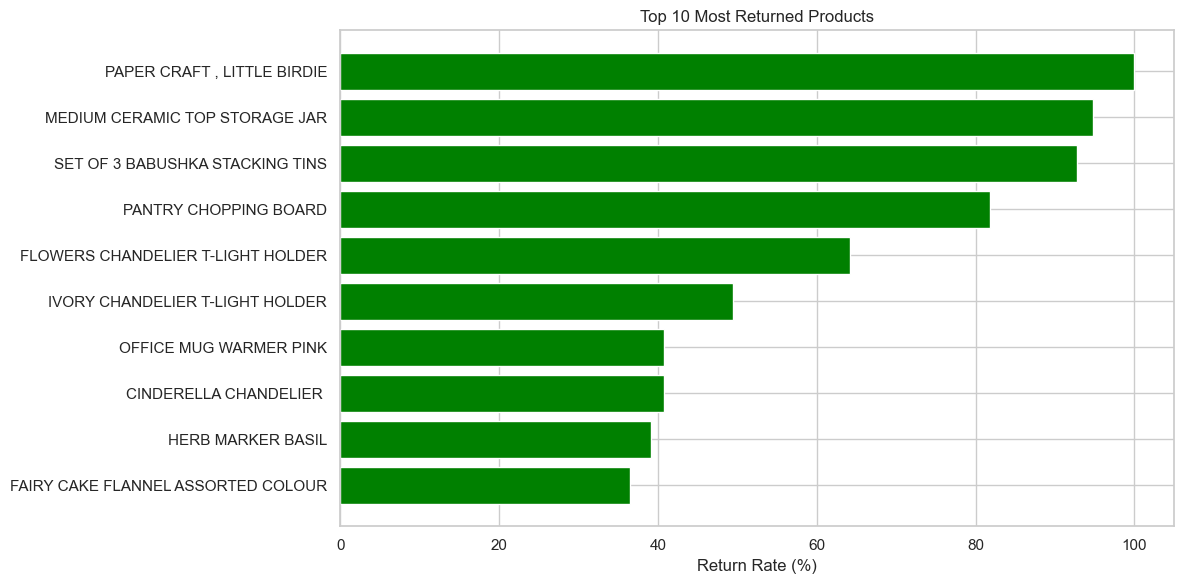

                                    SalesRevenue  ReturnRevenue  \
Description                                                       
PAPER CRAFT , LITTLE BIRDIE            168469.60     -168469.60   
MEDIUM CERAMIC TOP STORAGE JAR          81700.92      -77479.64   
SET OF 3 BABUSHKA STACKING TINS          1356.30       -1258.05   
PANTRY CHOPPING BOARD                    5868.50       -4803.06   
FLOWERS CHANDELIER T-LIGHT HOLDER        2898.12       -1859.07   
IVORY CHANDELIER T-LIGHT HOLDER          1395.18        -690.72   
OFFICE MUG WARMER PINK                   1564.83        -637.50   
CINDERELLA CHANDELIER                    3717.56       -1514.05   
HERB MARKER BASIL                        2153.34        -841.05   
FAIRY CAKE FLANNEL ASSORTED COLOUR      18056.28       -6591.42   

                                    ReturnRate (%)  
Description                                         
PAPER CRAFT , LITTLE BIRDIE             100.000000  
MEDIUM CERAMIC TOP STORAGE JAR      

In [699]:
# remove non-product items for comparison
non_product_keywords = ["FEE", "MANUAL", "ADJUST", "POSTAGE", "CREDIT", "CHARGES"]

def is_non_product(description):
    return any(keyword in description.upper() for keyword in non_product_keywords)

filtered_product_returns = product_return_analysis_filtered[
    ~product_return_analysis_filtered.index.to_series().apply(is_non_product)
]

top_returns_filtered = filtered_product_returns.head(10)

plt.figure(figsize=(12, 6))
plt.barh(top_returns_filtered.index, top_returns_filtered["ReturnRate (%)"], color='green')
plt.xlabel("Return Rate (%)")
plt.title("Top 10 Most Returned Products")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
print(top_returns_filtered)

MonthYear
2010-12     771378.640
2011-01     664274.750
2011-02     502389.330
2011-03     682904.590
2011-04     508998.021
2011-05     734070.170
2011-06     731104.870
2011-07     682929.521
2011-08     718114.250
2011-09    1015219.131
2011-10    1098668.630
2011-11    1443545.690
2011-12     612717.010
Freq: M, Name: TotalPrice, dtype: float64


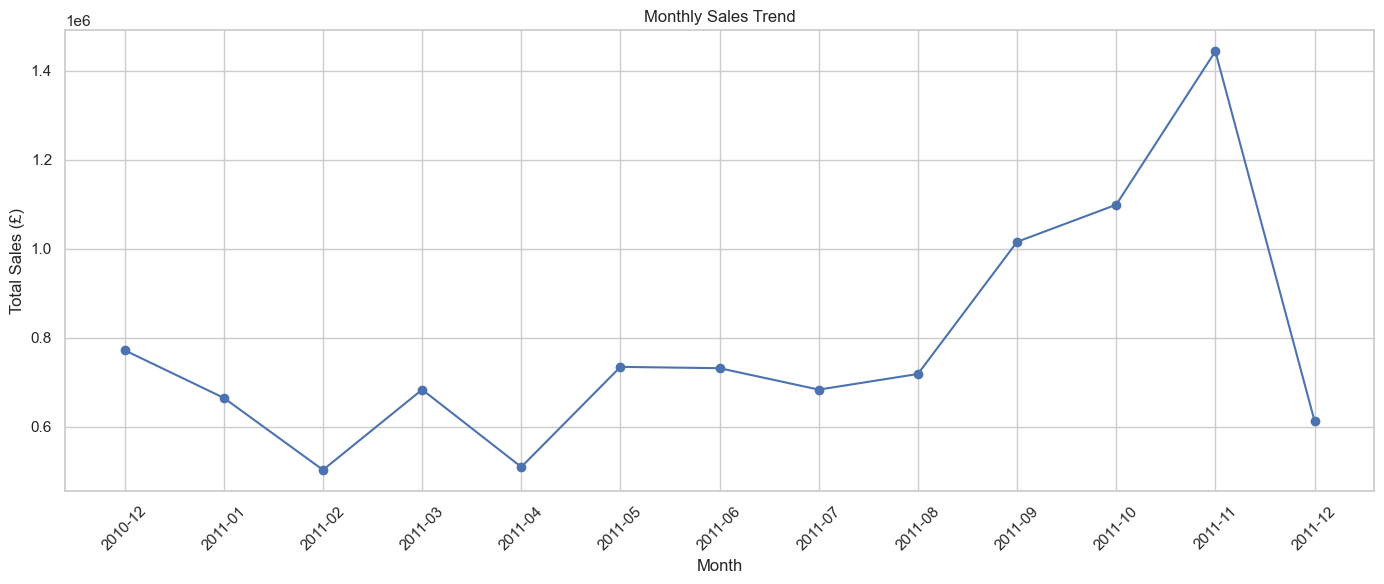

In [700]:
# Monthly sales
monthly_sales = filtered_sales_df.groupby('MonthYear')['TotalPrice'].sum()
monthly_net_sales = filtered_valid_txns.groupby('MonthYear')['TotalPrice'].sum()
print(monthly_sales)
monthly_net_sales
monthly_sales.index = monthly_sales.index.astype(str)
plt.figure(figsize=(14, 6))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', linestyle='-')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales (£)")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

YearQuarter
2010Q4     746723.610
2011Q1    1737488.950
2011Q2    1904439.171
2011Q3    2401264.253
2011Q4    2958215.090
Name: TotalPrice, dtype: float64


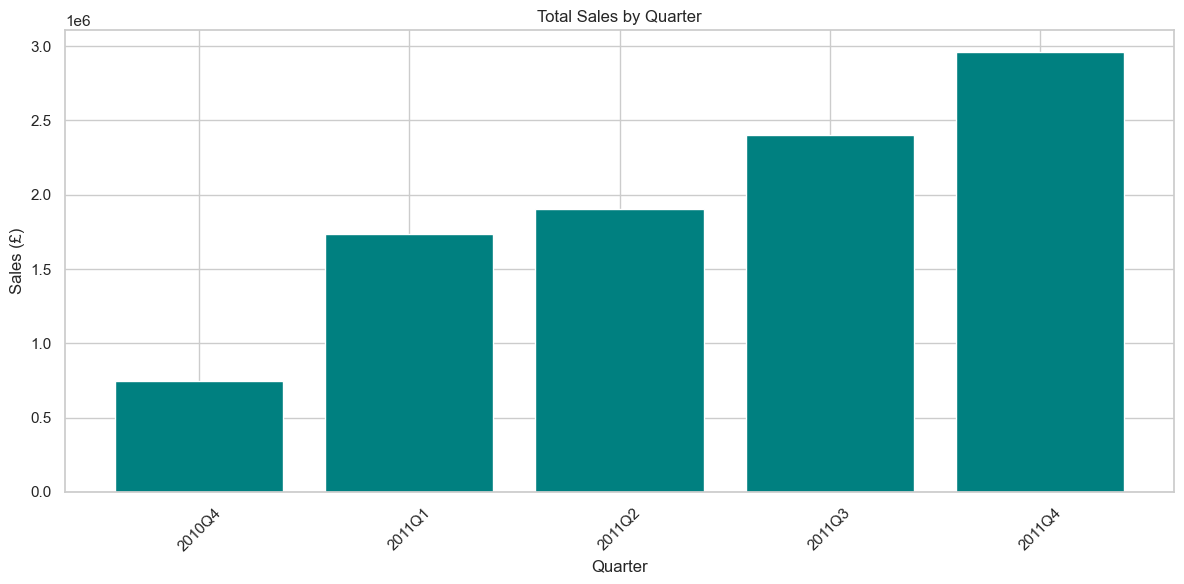

In [701]:
quarterly_sales = valid_txns.groupby('YearQuarter')['TotalPrice'].sum().sort_index()
quarterly_sales.index = quarterly_sales.index.astype(str)  # Convert Periods to strings for x-axis
print(quarterly_sales)
plt.figure(figsize=(12, 6))
plt.bar(quarterly_sales.index, quarterly_sales.values, color='teal')
plt.title("Total Sales by Quarter")
plt.xlabel("Quarter")
plt.ylabel("Sales (£)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

YearQuarter
2010Q4    497.663639
2011Q1    511.920473
2011Q2    446.241650
2011Q3    524.021449
2011Q4    566.313288
Name: TotalPrice, dtype: float64


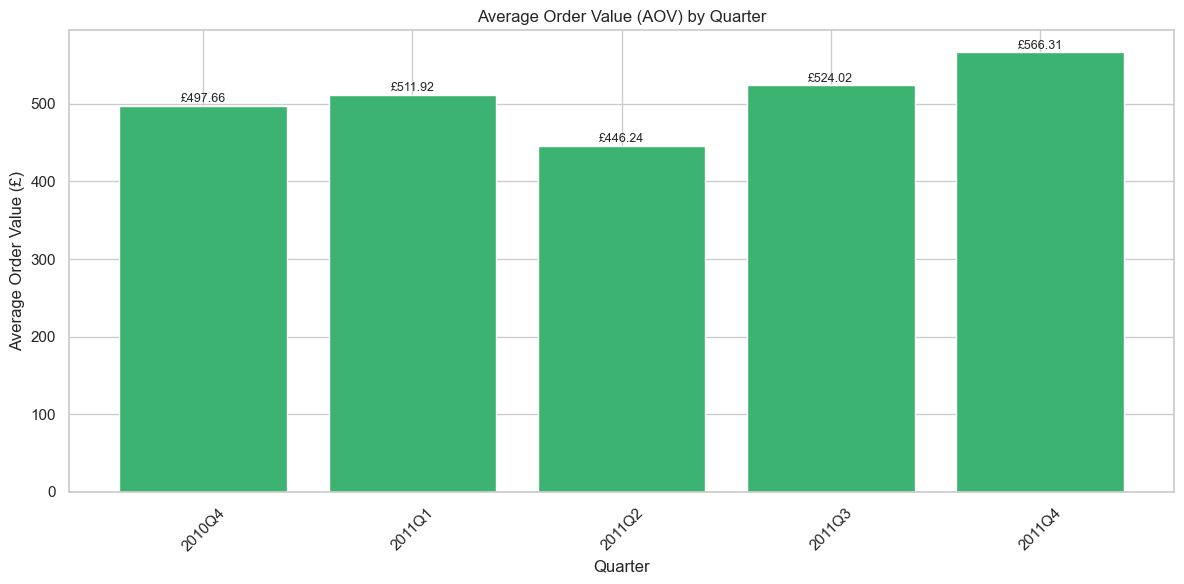

In [702]:
invoice_totals = filtered_sales_df.groupby(["YearQuarter", "InvoiceNo"])["TotalPrice"].sum()
aov_by_quarter = invoice_totals.groupby("YearQuarter").mean()
aov_by_quarter.index = aov_by_quarter.index.astype(str)  # Convert PeriodIndex to str for plotting
print(aov_by_quarter)

# Plot AOV by quarter
plt.figure(figsize=(12, 6))
plt.bar(aov_by_quarter.index, aov_by_quarter.values, color='mediumseagreen')
plt.title("Average Order Value (AOV) by Quarter")
plt.xlabel("Quarter")
plt.ylabel("Average Order Value (£)")
plt.xticks(rotation=45)

# Add labels to bars
for i, value in enumerate(aov_by_quarter.values):
    plt.text(i, value + 0.5, f"£{value:.2f}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

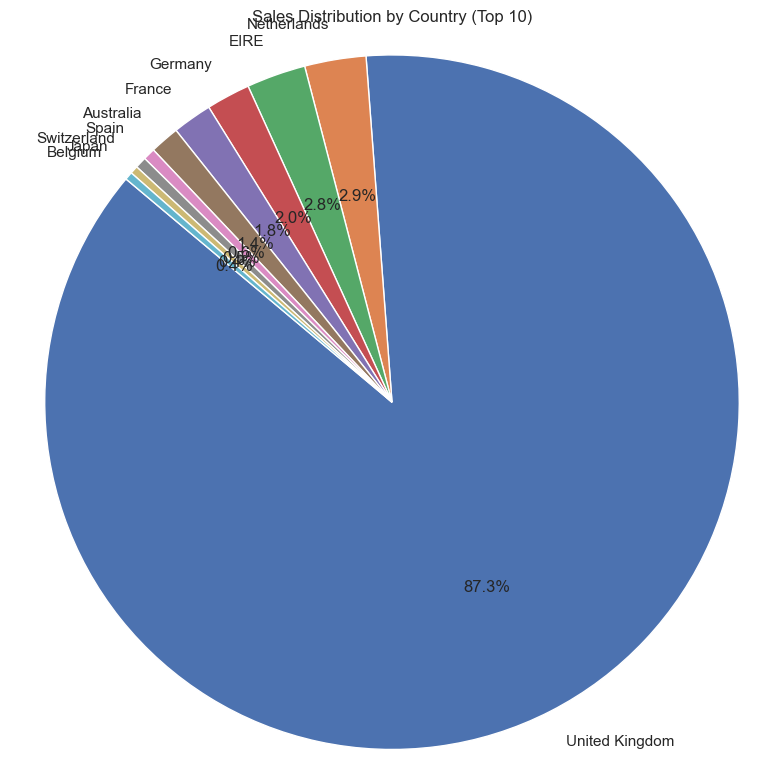

In [703]:
sales_by_country = (
    filtered_sales_df.groupby("Country")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
)

top_sales_countries = sales_by_country.head(10)
top_sales_countries

plt.figure(figsize=(8, 8))
plt.pie(
    top_sales_countries.values,
    labels=top_sales_countries.index,
    autopct="%1.1f%%",
    startangle=140,            
    wedgeprops={'edgecolor': 'white'}
)
plt.title("Sales Distribution by Country (Top 10)")
plt.axis("equal")
plt.tight_layout()
plt.show()

In [704]:
orders_by_time_of_day = filtered_sales_df.groupby('TimeOfDay', observed=False)['InvoiceNo'].nunique()
orders_by_time_of_day

TimeOfDay
Night            0
Morning       6779
Afternoon    12636
Evening        355
Name: InvoiceNo, dtype: int64

In [705]:
orders_by_hour = filtered_sales_df.groupby('Hour')['InvoiceNo'].nunique().sort_index()
orders_by_hour

Hour
6        1
7       29
8      565
9     1472
10    2339
11    2373
12    3203
13    2729
14    2417
15    2310
16    1315
17     662
18     192
19     145
20      18
Name: InvoiceNo, dtype: int64

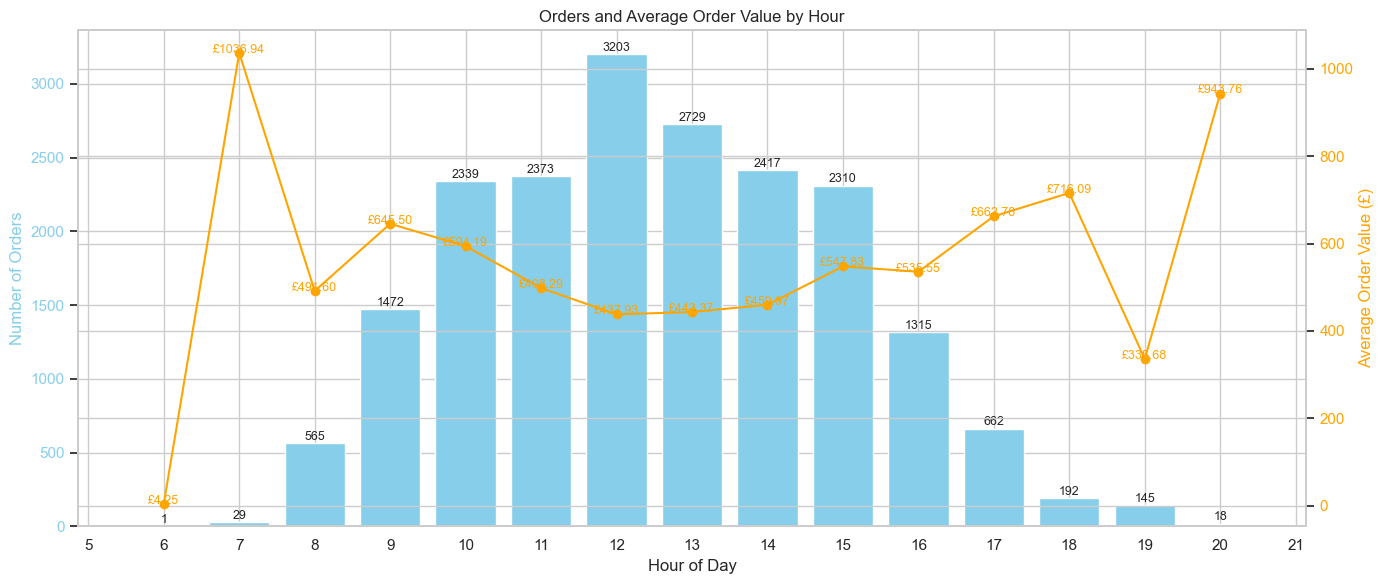

In [706]:
orders_by_hour = filtered_sales_df.groupby('Hour')['InvoiceNo'].nunique().sort_index()

order_value_by_hour = (filtered_sales_df.groupby(["Hour", "InvoiceNo"])["TotalPrice"].sum().groupby("Hour").mean())

fig, ax1 = plt.subplots(figsize=(14, 6))

bars = ax1.bar(orders_by_hour.index, orders_by_hour.values, color='skyblue', label='Number of Orders')
ax1.set_xlabel("Hour of Day")
ax1.set_ylabel("Number of Orders", color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')
ax1.set_xticks(range(0, 24))
ax1.set_title("Orders and Average Order Value by Hour")

# bar labels
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2, height + 1, f'{int(height)}', ha='center', va='bottom', fontsize=9)

ax2 = ax1.twinx()
line = ax2.plot(order_value_by_hour.index, order_value_by_hour.values, color='orange', marker='o', label='Avg Order Value (£)')
ax2.set_ylabel("Average Order Value (£)", color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

# line chart labels
for i, value in enumerate(order_value_by_hour.values):
    ax2.text(order_value_by_hour.index[i], value + 0.5, f"£{value:.2f}", color='orange', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

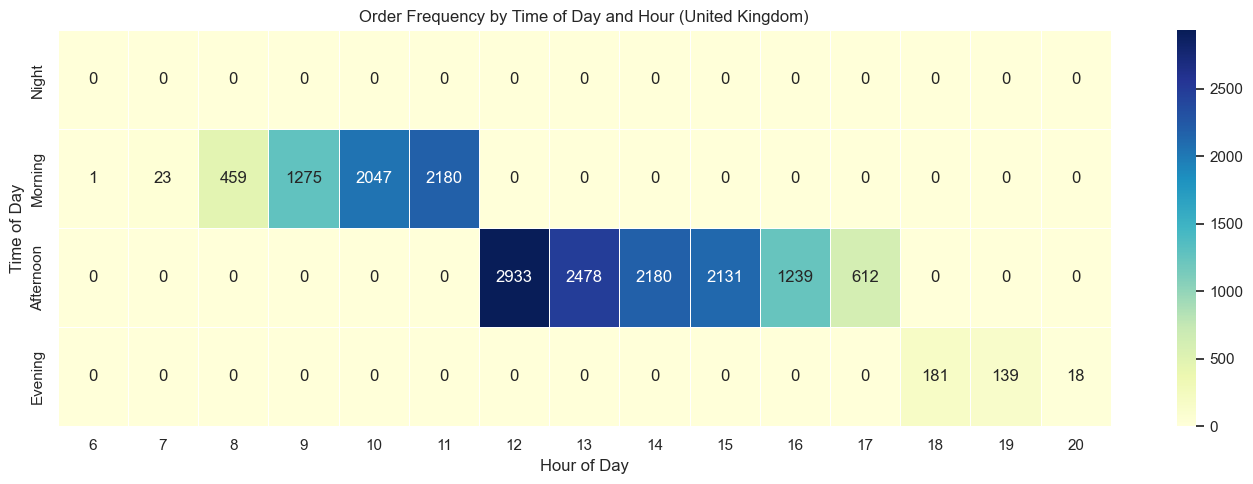

In [707]:
country_sales = filtered_sales_df[filtered_sales_df["Country"] == "United Kingdom"]
time_hour_data = (country_sales.groupby(["TimeOfDay", "Hour"], observed=False)["InvoiceNo"].nunique().reset_index())
heatmap_data = time_hour_data.pivot(index="TimeOfDay", columns="Hour", values="InvoiceNo").fillna(0)

plt.figure(figsize=(14, 5))
sns.heatmap(heatmap_data, cmap="YlGnBu", linewidths=0.5, annot=True, fmt=".0f")
plt.title("Order Frequency by Time of Day and Hour (United Kingdom)")
plt.xlabel("Hour of Day")
plt.ylabel("Time of Day")
plt.tight_layout()
plt.show()

In [708]:
customer_orders = filtered_sales_df.groupby("CustomerID")["InvoiceNo"].nunique()
repeat_customers = customer_orders[customer_orders > 1].count()
repeat_ratio = repeat_customers / num_customers
print(f"Repeat Customer Ratio: {repeat_ratio:.2%}")

Repeat Customer Ratio: 65.27%


In [709]:
no_orders_per_customer = customer_orders.sort_values(ascending=False)
no_orders_per_customer.head(10).to_frame(name="Number of Orders").style \
    .set_caption("Top 10 Customers by Number of Orders") \
    .format(precision=0) \
    .background_gradient(cmap="Blues")

,Number of Orders
CustomerID,
12748,206
14911,199
17841,124
13089,97
15311,91
14606,90
12971,86
14646,72
16029,62


In [710]:
customer_returns = filtered_returns_df.groupby("CustomerID")["InvoiceNo"].nunique()
frequent_returners = customer_returns.sort_values(ascending=False)
frequent_returners.head(10).to_frame(name="Number of Returns").style \
    .set_caption("Top 10 Customers by Number of Returns") \
    .format(precision=0) \
    .background_gradient(cmap="Reds")

,Number of Returns
CustomerID,
17841,45
14911,44
14606,35
15311,27
13089,21
12471,18
13534,18
13078,17
14096,16
